## Fuente de datos
Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 
pd.options.display.float_format = '{:.2f}'.format
sns.set_theme(context="talk")

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"
SALUD_ORANGE  = "#E65100"  # naranja intenso accesible
SALUD_GREEN   = "#2E7D32"  # verde profundo
SALUD_PURPLE  = "#6A1B9A"  # violeta fuerte
SALUD_MAROON  = "#8E2430"  # bordó elegante
SALUD_GRAY    = "#424242"  # gris oscuro neutro
SALUD_OLIVE   = "#827717"  # oliva contrastante



In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
#import locale

#locale.setlocale(locale.LC_ALL, 'es_ES.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'
#es_AR.UTF-8

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})




### Lectura de datos


In [4]:
### CONFIGURACION DATOS
BASE_DIR =  os.getenv("DIR_BASE")
sys.path.append(BASE_DIR)
pd.set_option('display.max_colwidth', None)
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(RESULTADOS_DIR)

In [5]:
# abrir el archivo binario proyecto filtrado
with open(RESULTADOS_DIR+'proyecto_2009_2024_LIMPIO2_df.pkl', 'rb') as file:
    proyecto_2009_2024_LIMPIO_df = pickle.load(file)

In [6]:
proyecto_2009_2024_LIMPIO_df.columns

Index(['Proyecto.ID', 'Título', 'Publicación.Fecha', 'Publicación.ID',
       'Exp..Diputados', 'Tipo', 'Max_Orden',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Tiene_info_movimiento', 'Duración_dias_prep', 'Años_mes', 'Año', 'Mes',
       'Nombre_dia_semana', 'Tiempo_desde_public_anterior',
       'Tiempo_desde_Proyecto.ID_anterior', 'ID', 'Diferencia_ID',
       'Tiene_antecedente_por_titulo_proy', 'Fecha', 'Periodo'],
      dtype='object')

In [7]:
# Función para preparar datos
def preparar_resumen_salud(df):

    # Preparar datos
    summary_df = df.groupby('Periodo').agg(
        total_proyectos=('Proyecto.ID', 'count'),
        proyectos_salud=('Proyecto_SALUD', 'sum')
    ).reset_index()
    
    summary_df['pct_salud'] = (summary_df['proyectos_salud'] / summary_df['total_proyectos']) * 100
    summary_df['proyectos_nosalud'] = summary_df['total_proyectos'] -  summary_df['proyectos_salud']
    
    # Datos para gráficos de torta
    total_proyectos = summary_df['total_proyectos'].sum()
    total_salud = summary_df['proyectos_salud'].sum()
    total_no_salud = total_proyectos - total_salud
    
    return summary_df, total_proyectos, total_salud, total_no_salud


# Función personalizada para mostrar valor y porcentaje con formato accesible
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:d}\n({pct:.2f}%)'
            #f"{locale.format_string('%d', val, grouping=True)}\n"
            #f"({locale.format_string('%.2f', pct)}%)"
        
        #return f'{val:,}\n({pct:.2f}%)'
    return my_autopct


# Función para generar gráfica
def plot_torta_salud(labels_pie1,sizes_pie1,colors_pie1,figfile):

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))  # Tamaño aumentado para mejor legibilidad
    # Crear el gráfico de torta

    wedges, texts, autotexts = ax.pie(
        sizes_pie1,
        labels=labels_pie1,
        colors=colors_pie1,
        autopct=make_autopct(sizes_pie1),
        startangle=90,
        pctdistance=1.15,
        labeldistance=1.05
        #textprops={'fontsize': 14}
    )
    
    
    # Alinear textos de labels y porcentajes a la izquierda
    for text in texts:
        text.set_fontsize(18)
        text.set_ha('left')
    
    
    for autotext in autotexts:
        autotext.set_ha('left')
        autotext.set_fontsize(18)
    
    # Forzar alineación vertical tipo columna
    for i, (text, autotext) in enumerate(zip(texts, autotexts)):
        x_text, y_text = text.get_position()
        x_auto, y_auto = autotext.get_position()
    
        # Forzar misma X para todos (columna a la derecha del gráfico)
        new_x = .50
        text.set_position((new_x, y_text))
        autotext.set_position((new_x, y_auto))

    # Reordenar visualmente SIN forzar columna
    for text, autotext in zip(texts, autotexts):
        x, y = text.get_position()
    
        # label un poco más arriba
        text.set_position((x, y + 0.1))
    
        # valor + porcentaje un poco más abajo
        autotext.set_position((x, y - 0.05))
    #ax.set_title('Distribución porcentual de Proyectos legislativos según clasificación (comisión cabecera) \n', pad=20, fontsize=14,fontweight='bold')
    #ax.axis('equal')
    
    
    # --- AJUSTES FINALES ---
    plt.tight_layout(pad=3)
    plt.subplots_adjust(bottom=0.25, right=0.85)  # Más espacio para leyenda y texto
    
    # Guardar en alta calidad para accesibilidad
    # BASE_DIR+'imagenes/proyectosTotalvsSalud_accesible.png'
    plt.savefig( figfile, 
                dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    
    plt.show()
    # Limpiar para próximos gráficos
    plt.cla()
    plt.clf()
    plt.close(fig)

### Distribución de proyectos sobre salud, otros y total

La base de datos final integrada comprende 92.535 proyectos (leyes, resoluciones, declaraciones y mensajes) correspondientes a los períodos parlamentarios 127 a 141 (años 2009 a 2024). De este total, 8.244 proyectos (8,91 %) fueron clasificados como vinculados a la temática de salud, como se ve en Figura 3.3, según el criterio de la primera comisión tratante (Honorable Cámara de Diputados de la Nación Argentina 2022).

El análisis exploratorio de la base de datos de proyectos legislativos mostró un incremento excepcional en la cantidad de iniciativas vinculadas a la salud durante el período parlamentario 138 seguído por el periodo 139 . En este período se registraron 1.192 proyectos (18,17 % del total), cifra que contrasta con el promedio de 550 proyectos por período (8,97 %). Este aumento notable puede estar relacionado a el contexto de la pandemia de COVID-19 desarrollada entre 2020 y 2021 (véase la Figura 3.4).

In [8]:
# Preparar datos
summary_df, total_proyectos, total_salud, total_no_salud = preparar_resumen_salud(proyecto_2009_2024_LIMPIO_df)
summary_df['Periodo'] = summary_df['Periodo'].astype(int)
summary_df['proyectos_salud'] = summary_df['proyectos_salud'].astype(int)
summary_df['proyectos_nosalud'] = summary_df['proyectos_nosalud'].astype(int)
summary_df

,Periodo,total_proyectos,proyectos_salud,pct_salud,proyectos_nosalud
0,127,5382,554,10.29,4828
1,128,7682,591,7.69,7091
2,129,5784,440,7.61,5344
3,130,7321,514,7.02,6807
4,131,6598,530,8.03,6068
5,132,8158,648,7.94,7510
6,133,5564,435,7.82,5129
7,134,6621,461,6.96,6160
8,135,5821,421,7.23,5400
9,136,6851,550,8.03,6301


#### Figura 3.3

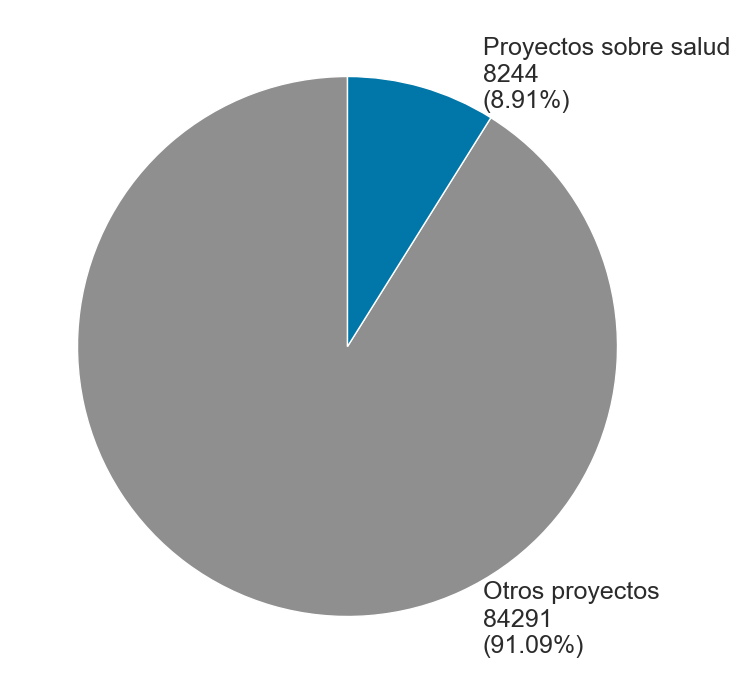

<Figure size 800x500 with 0 Axes>

In [9]:
# --- GRÁFICO 1: TORTA - TOTAL PROYECTOS VS SALUD ---
labels_pie1 = ['Otros proyectos', 'Proyectos sobre salud']
sizes_pie1 = [total_no_salud, total_salud]

# Paleta de colores accesible para daltonismo (protanopia, deuteranopia)
# Colores con alto contraste y diferenciables para la mayoría de tipos de daltonismo

colors_pie1 = [GRAY_MAIN, HEALTH_CYAN] 

# Dirección para guarda gráfica
figfile = BASE_DIR+'imagenes/proyectosTotalvsSalud_accesible.png'

# Crear gráfica
plot_torta_salud(labels_pie1,sizes_pie1,colors_pie1,figfile)

#### Figura 3.4

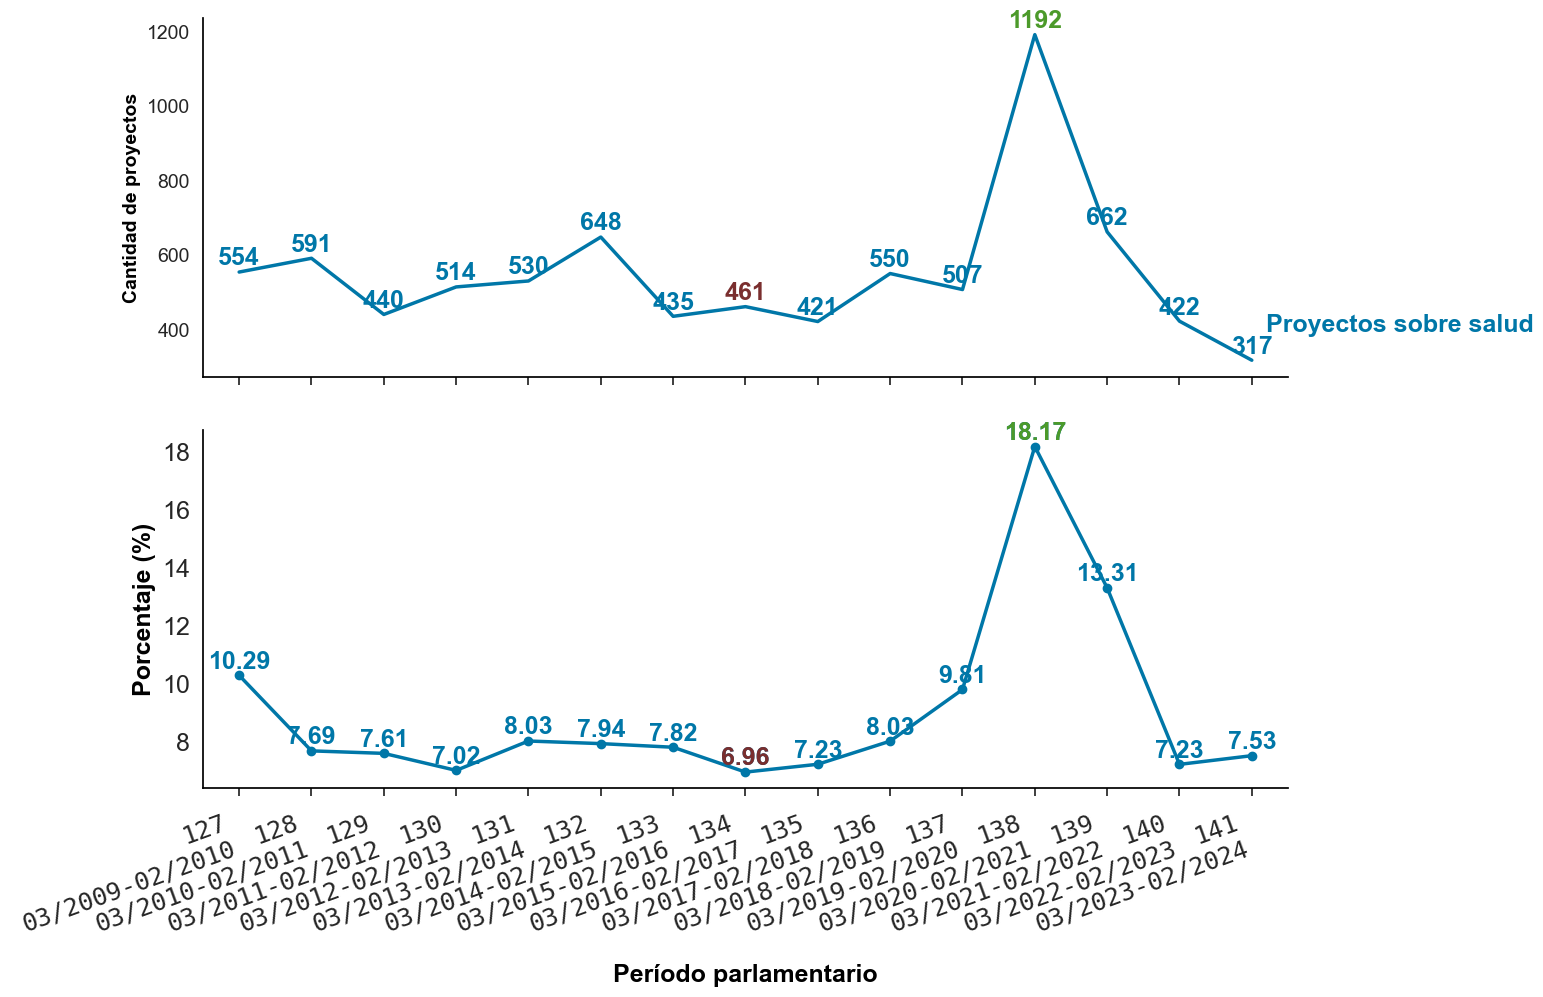

In [10]:
# Configurar el estilo y crear la grilla
from matplotlib.ticker import PercentFormatter

period_dict = {
        127: '03/2009-02/2010',
        128: '03/2010-02/2011',
        129: '03/2011-02/2012',
        130: '03/2012-02/2013',
        131: '03/2013-02/2014',
        132: '03/2014-02/2015',
        133: '03/2015-02/2016',
        134: '03/2016-02/2017',
        135: '03/2017-02/2018',
        136: '03/2018-02/2019',
        137: '03/2019-02/2020', 
        138: '03/2020-02/2021', 
        139: '03/2021-02/2022',
        140: '03/2022-02/2023',
        141: '03/2023-02/2024',
    }

def periodos_a_fechas(periodo):
    
    if periodo in period_dict:
        return f'{periodo}\n{period_dict[periodo]}'
    return ''

def label_line_end(ax, x, y, label, color, offset=(5, 0)):
    return ax.annotate(
        label,
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        color=color,
        fontsize=18,
        fontweight='bold',
        va='center'
    )


# Configurar el estilo con colores accesibles
#plt.style.use('default')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
# Colores accesibles (contraste adecuado y distinguibles para daltónicos)
colors = {
    'total_proyectos': '#2F2F2F', #GRAY_LIGHT,
    'proyectos_nosalud': GRAY_MAIN , 
    'proyectos_salud': HEALTH_CYAN, 
    'pct_salud': HEALTH_CYAN,        
    'grid': '#cccccc',
    'text': 'black'
}

offset= (6, 0)
RED_HEALTH   = "#7A2E2E"
#GREEN_HEALTH = "#8FBFA8"
GREEN_HEALTH = "#4C9A2A" #"#3E8E7E"

# --- GRÁFICO 1: LÍNEA - TENDENCIA ANUAL (FRECUENCIA ABSOLUTA) ---
#line_total = ax1.plot(summary_df['Periodo'], summary_df['total_proyectos'], 
#         marker='', linewidth=1, label='Total proyectos',
#         color=colors['total_proyectos'])

line_salud = ax1.plot(summary_df['Periodo'], summary_df['proyectos_salud'], 
         marker='', linewidth=2.5, label='Proyectos sobre salud',
         color=colors['proyectos_salud'])


#line_nosalud = ax1.plot(summary_df['Periodo'], summary_df['proyectos_nosalud'], 
#         marker='', linewidth=1, label='Otros proyectos',
#         color=colors['proyectos_nosalud'], markersize=6)

ax1.set_ylabel('Cantidad de proyectos', fontsize=14, fontweight='bold', color=colors['text'])
#ax1.set_title('Distribución de proyectos por período parlamentario', fontweight='bold', fontsize=14, pad=20)
#ax1.legend(loc='upper right', framealpha=0.9)
ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=False)  # Ocultar labels del x-axis superior
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# Añadir valores en los puntos
for i, (periodo, total,  salud) in enumerate(zip(summary_df['Periodo'], 
                                              summary_df['total_proyectos'],
                                              #summary_df['proyectos_nosalud'] , 
                                              summary_df['proyectos_salud'])):

    
    if periodo not in [134,138]:
        ax1.annotate(salud ,#locale.format_string('%d', int(salud), grouping=True), 
                     xy=(periodo, salud),
                     xytext=(0, 5), textcoords='offset points',  
                     ha='center', fontsize=18, fontweight='bold',
                     color=colors['proyectos_salud'])


    if periodo == 134:
        # Anotaciones para total proyectos (arriba del punto)
        #ax1.annotate( total, #locale.format_string('%d', int(total), grouping=True), 
        #             xy=(periodo, total),
        #             xytext=(0, 5), textcoords='offset points', 
        #             ha='center', fontsize=14, fontweight='bold',
        #             color=RED_HEALTH)
        ax1.annotate( salud, # locale.format_string('%d', int(salud), grouping=True), 
                 xy=(periodo, salud),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=RED_HEALTH)


    if periodo == 138:
        # Anotaciones para total proyectos (arriba del punto)
        #ax1.annotate(total, #locale.format_string('%d', int(total), grouping=True), 
        #             xy=(periodo, total),
        #             xytext=(0, 5), textcoords='offset points', 
        #             ha='center', fontsize=14, fontweight='bold',
        #             color=GREEN_HEALTH)
        ax1.annotate(salud, #locale.format_string('%d', int(salud), grouping=True),  
                 xy=(periodo, salud),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center',fontsize=18,  fontweight='bold',
                 color=GREEN_HEALTH)

    

    
label_line_end(ax1, summary_df['Periodo'].iloc[-1], summary_df['proyectos_salud'].iloc[-1],
           'Proyectos sobre salud', colors['proyectos_salud'],offset=(10, 25))
    
#label_line_end(ax1, summary_df['Periodo'].iloc[-1], summary_df['proyectos_nosalud'].iloc[-1],
#           'Otros proyectos', colors['proyectos_nosalud'],offset=(0, 15))
    
#label_line_end(ax1, summary_df['Periodo'].iloc[-1], summary_df['total_proyectos'].iloc[-1],
#           'Total proyectos', colors['total_proyectos'],offset=(10, 25))


# --- GRÁFICO 2: LÍNEA - TENDENCIA ANUAL (FRECUENCIA RELATIVA) ---
ax2.plot(summary_df['Periodo'], summary_df['pct_salud'],  # Convertir a porcentaje
         marker='o', linewidth=2.5, color=colors['pct_salud'], 
         label='% Proyectos sobre salud', markersize=6)

ax2.set_xlabel('Período parlamentario', fontsize=18, fontweight='bold', color=colors['text'])
ax2.set_ylabel('Porcentaje (%)', fontsize=18, fontweight='bold', color=colors['text'])
    
#label_line_end(ax2, summary_df['Periodo'].iloc[-1], summary_df['pct_salud'].iloc[-1],
#           '% Proyectos sobre salud', colors['pct_salud'],offset=(10, 25))

#ax2.legend(loc='upper right', framealpha=0.9, ncols = 2)
#ax2.grid(True, alpha=0.4, color=colors['grid'])
#ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Configurar los ticks del eje X con las fechas
xticks = sorted(summary_df['Periodo'].unique())
xtick_labels = [periodos_a_fechas(x) for x in xticks]
ax2.tick_params(axis='y', labelsize=18)
#ax2.tick_params(axis='x', labelsize=14)


ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels, 
                   rotation=20, 
                   ha='right', 
                   fontsize=14,           # Tamaño de fuente más grande
                   family='monospace')    # Fuente monoespaciada para mejor alineación
# Ajustar los márgenes para que las etiquetas no se corten
ax2.tick_params(axis='x', which='major', pad=10, bottom=True,labelsize=18)  # Más espacio entre labels y eje

# Añadir fondo alternado para mejor lectura
ax2.set_axisbelow(True)
for i, periodo in enumerate(xticks):
    if i % 2 == 0:  # Fondos alternados
        ax2.axvspan(periodo - 0.4, periodo + 0.4, alpha=0.05, color='white')

# Ajustar los límites del eje X para mejor visualización
ax2.set_xlim(xticks[0] - 0.5, xticks[-1] + 0.5)

# Añadir título descriptivo al eje X
ax2.set_xlabel('Período parlamentario', 
              fontsize=18, 
              fontweight='bold', 
              labelpad=20)

# Añadir valores de porcentaje
for i, (periodo, pct) in enumerate(zip(summary_df['Periodo'], summary_df['pct_salud'])):
    ax2.annotate( f"{pct:,.2f}", #(f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=colors['pct_salud'])
    if periodo == 134:
             ax2.annotate( f"{pct:,.2f}",#f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=RED_HEALTH #  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none')
                )
    if periodo == 138:    
             ax2.annotate( f"{pct:,.2f}", #f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=GREEN_HEALTH)



for ax in [ax1, ax2]:
    # Quitar cualquier grilla activa
    ax.grid(False)

    # Ocultar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mantener solo los ejes izquierdo e inferior en negro
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')



ax1.set_facecolor('white')
ax2.set_facecolor('white')




# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/evolucion_proyectos.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Ajustar el espacio entre subplots
plt.subplots_adjust(hspace=0.15)
# --- AJUSTES FINALES ---
#plt.tight_layout(pad=2)
#plt.subplots_adjust(hspace=0.1, bottom=0.25)  # Ajustar espacio inferior
plt.show()

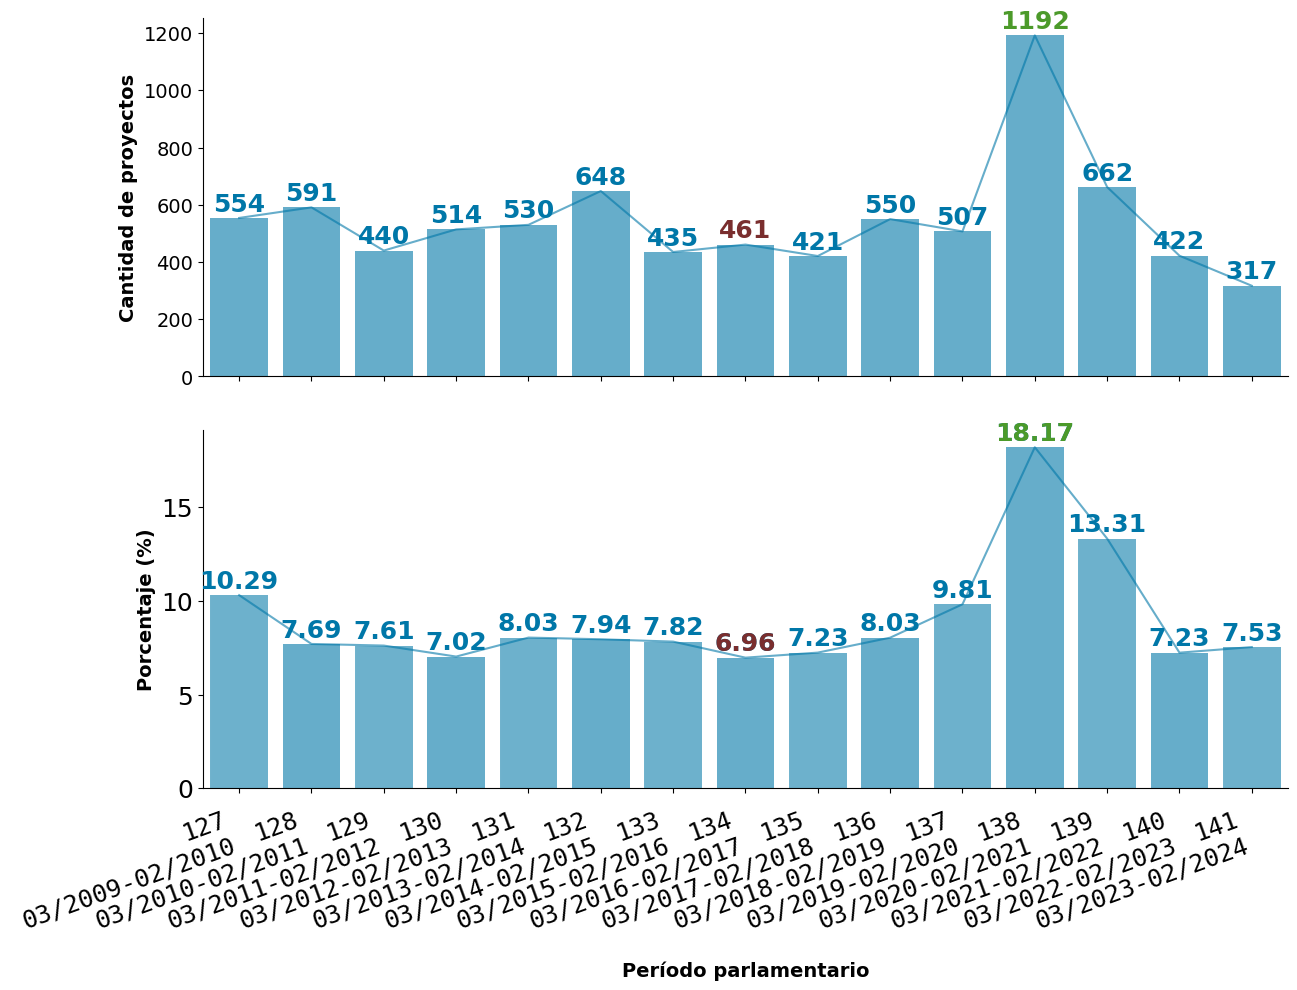

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- GRÁFICO 1: BARRAS + LÍNEA SUAVE ---

# Barras
ax1.bar(summary_df['Periodo'], summary_df['proyectos_salud'],
        color=colors['proyectos_salud'], alpha=0.6, label='Proyectos sobre salud')

# Línea original (opcional muy suave)
ax1.plot(summary_df['Periodo'], summary_df['proyectos_salud'],
         linewidth=1.5, color=colors['proyectos_salud'], alpha=0.6)

ax1.set_ylabel('Cantidad de proyectos', fontsize=14, fontweight='bold', color=colors['text'])
#ax1.set_title('Distribución de proyectos por período parlamentario', fontweight='bold', fontsize=14, pad=20)
#ax1.legend(loc='upper right', framealpha=0.9)
ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=False)  # Ocultar labels del x-axis superior
ax1.tick_params(axis='y', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# Añadir valores en los puntos
for i, (periodo, total,  salud) in enumerate(zip(summary_df['Periodo'], 
                                              summary_df['total_proyectos'],
                                              #summary_df['proyectos_nosalud'] , 
                                              summary_df['proyectos_salud'])):

    
    if periodo not in [134,138]:
        ax1.annotate(salud ,#locale.format_string('%d', int(salud), grouping=True), 
                     xy=(periodo, salud),
                     xytext=(0, 5), textcoords='offset points',  
                     ha='center', fontsize=18, fontweight='bold',
                     color=colors['proyectos_salud'])


    if periodo == 134:
        # Anotaciones para total proyectos (arriba del punto)
        #ax1.annotate( total, #locale.format_string('%d', int(total), grouping=True), 
        #             xy=(periodo, total),
        #             xytext=(0, 5), textcoords='offset points', 
        #             ha='center', fontsize=14, fontweight='bold',
        #             color=RED_HEALTH)
        ax1.annotate( salud, # locale.format_string('%d', int(salud), grouping=True), 
                 xy=(periodo, salud),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=RED_HEALTH)


    if periodo == 138:
        # Anotaciones para total proyectos (arriba del punto)
        #ax1.annotate(total, #locale.format_string('%d', int(total), grouping=True), 
        #             xy=(periodo, total),
        #             xytext=(0, 5), textcoords='offset points', 
        #             ha='center', fontsize=14, fontweight='bold',
        #             color=GREEN_HEALTH)
        ax1.annotate(salud, #locale.format_string('%d', int(salud), grouping=True),  
                 xy=(periodo, salud),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center',fontsize=18,  fontweight='bold',
                 color=GREEN_HEALTH)


# --- GRÁFICO 2: BARRAS + LÍNEA SUAVE ---

# Barras
ax2.bar(summary_df['Periodo'], summary_df['pct_salud'],
        color=colors['pct_salud'], alpha=0.6)

# Línea original
ax2.plot(summary_df['Periodo'], summary_df['pct_salud'],
         linewidth=1.5, color=colors['pct_salud'], alpha=0.6)


ax2.set_xlabel('Período parlamentario', fontsize=14, fontweight='bold', color=colors['text'])
ax2.set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold', color=colors['text'])
    
#label_line_end(ax2, summary_df['Periodo'].iloc[-1], summary_df['pct_salud'].iloc[-1],
#           '% Proyectos sobre salud', colors['pct_salud'],offset=(10, 25))

#ax2.legend(loc='upper right', framealpha=0.9, ncols = 2)
#ax2.grid(True, alpha=0.4, color=colors['grid'])
#ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Configurar los ticks del eje X con las fechas
xticks = sorted(summary_df['Periodo'].unique())
xtick_labels = [periodos_a_fechas(x) for x in xticks]
ax2.tick_params(axis='y', labelsize=18)
#ax2.tick_params(axis='x', labelsize=14)


ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels, 
                   rotation=20, 
                   ha='right', 
                   fontsize=14,           # Tamaño de fuente más grande
                   family='monospace')    # Fuente monoespaciada para mejor alineación
# Ajustar los márgenes para que las etiquetas no se corten
ax2.tick_params(axis='x', which='major', pad=10, bottom=True,labelsize=18)  # Más espacio entre labels y eje

# Añadir fondo alternado para mejor lectura
ax2.set_axisbelow(True)
for i, periodo in enumerate(xticks):
    if i % 2 == 0:  # Fondos alternados
        ax2.axvspan(periodo - 0.4, periodo + 0.4, alpha=0.05, color='white')

# Ajustar los límites del eje X para mejor visualización
ax2.set_xlim(xticks[0] - 0.5, xticks[-1] + 0.5)

# Añadir título descriptivo al eje X
ax2.set_xlabel('Período parlamentario', 
              fontsize=14, 
              fontweight='bold', 
              labelpad=20)

# Añadir valores de porcentaje
for i, (periodo, pct) in enumerate(zip(summary_df['Periodo'], summary_df['pct_salud'])):
    ax2.annotate( f"{pct:,.2f}", #(f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=colors['pct_salud'])
    if periodo == 134:
             ax2.annotate( f"{pct:,.2f}",#f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=RED_HEALTH #  bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none')
                )
    if periodo == 138:    
             ax2.annotate( f"{pct:,.2f}", #f"{locale.format_string('%.2f', pct)}",
                 xy=(periodo, pct),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=18, fontweight='bold',
                 color=GREEN_HEALTH)



for ax in [ax1, ax2]:
    # Quitar cualquier grilla activa
    ax.grid(False)

    # Ocultar bordes superior y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mantener solo los ejes izquierdo e inferior en negro
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')



ax1.set_facecolor('white')
ax2.set_facecolor('white')




# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/evolucion_proyectos.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Ajustar el espacio entre subplots
plt.subplots_adjust(hspace=0.15)
# --- AJUSTES FINALES ---
#plt.tight_layout(pad=2)
#plt.subplots_adjust(hspace=0.1, bottom=0.25)  # Ajustar espacio inferior
plt.show()

Del total de 8.244 proyectos asociados a temas de salud, 2.848 (34,55 %) corresponden específicamente a proyectos de ley. Sobre esta muestra se realiza el estudio de detección de cambios semánticos.

In [25]:
"""
paleta_salud = {
    'ley': HEALTH_CYAN,
    'resolucion': '#FFB300', #'#4A148C',#'#D81B60',
    'declaracion': '#4A148C', #'#FFB300',#'#2E7D32',
    'otros (<1%)': '#D81B60',
}

paleta_salud = {
    'ley': '#0077A8',        # Azul institucional
    'resolucion': '#37474F', # Gris azulado profundo (muy elegante)
    'declaracion': '#6A1B9A',# Violeta oscuro sobrio
    'otros (<1%)': '#B0BEC5' # Gris claro neutro
}
"""
paleta_salud = {
    'Proyecto de Ley': '#0077A8',        # azul institucional (gris medio)
    'Resolución': '#1A1A1A', # casi negro (gris muy oscuro)
    'Declaración': '#9FAFB8',# gris claro frío
    'Otros (<1%)': '#E8EFF3' # gris muy claro
}

In [26]:
HEALTH_CYAN

'#0077A8'

In [27]:
# --- GRÁFICO: TORTA - PROYECTOS DE SALUD POR TIPO ---

if 'tipo_salud_counts' not in locals():
    # Si no existe, calcularlo desde el DataFrame
    tipo_salud_counts = proyecto_2009_2024_LIMPIO_df[proyecto_2009_2024_LIMPIO_df['Proyecto_SALUD'] == 1]['Tipo'].value_counts()
    tipo_salud_counts = tipo_salud_counts.sort_values(ascending=False)




# Calcular porcentajes
total = tipo_salud_counts.sum()
tipo_salud_pct = (tipo_salud_counts / total) * 100

# Separar categorías
mayores_1 = tipo_salud_counts[tipo_salud_pct >= 1]
menores_1 = tipo_salud_counts[tipo_salud_pct < 1]


# Agrupar menores al 1%
if len(menores_1) > 0:
    mayores_1['OTROS (<1%)'] = menores_1.sum()
    
mayores_1

Tipo
RESOLUCION     4032
LEY            2848
DECLARACION    1361
OTROS (<1%)       3
Name: count, dtype: int64

In [29]:
map_labels = {
    'RESOLUCION': 'Resolución',
    'LEY': 'Proyecto de Ley',
    'DECLARACION': 'Declaración',
    'OTROS (<1%)': 'Otros (<1%)',
}

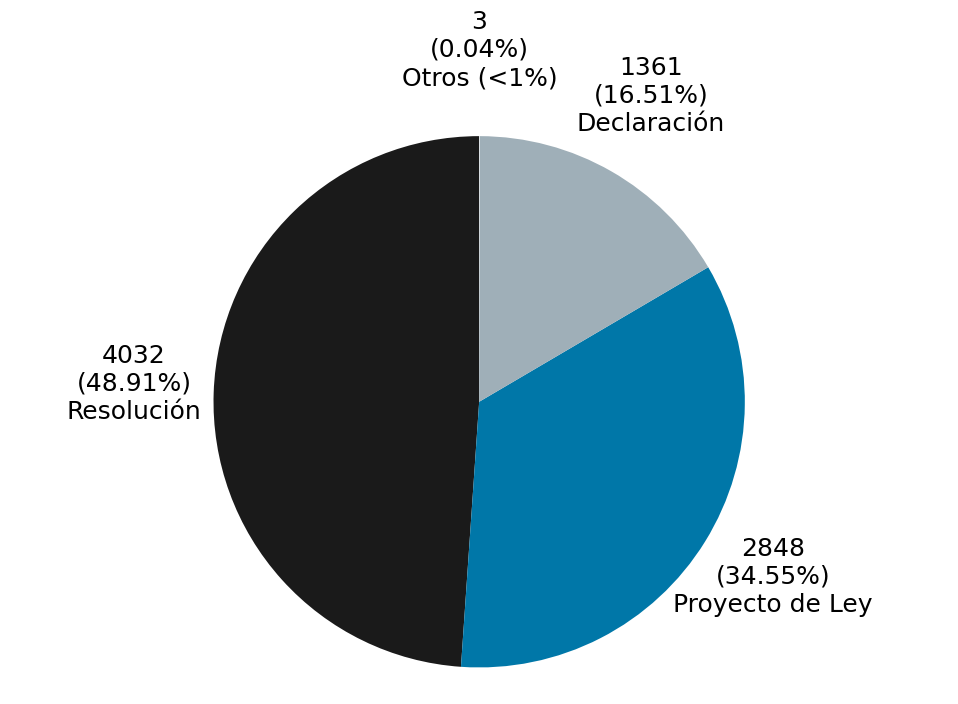

<Figure size 640x480 with 0 Axes>

In [30]:
menores_1.index[0]


fig, ax = plt.subplots(1, 1, figsize=(14, 10)) 

# Usar esto para el gráfico
#labels_pie2 = mayores_1.index.str.lower().tolist()

labels_original = mayores_1.index.tolist()
labels_pie2 = [map_labels.get(label, label) for label in labels_original]
sizes_pie2 = mayores_1.values.tolist()

# Paleta de colores accesible para daltonismo con 4 colores diferenciables
colors_pie2 =  [
    paleta_salud.get(label, "#9E9E9E")  # fallback gris si no existe
    for label in labels_pie2
] 

total = sum(sizes_pie2)

labels_final = [
    f"{v:,.0f} ({v/total:.1%})\n{lab}"
    for lab, v in zip(labels_pie2, sizes_pie2)
]


 # total = sum(values)
 #       val = int(round(pct * total / 100.0))
 #       return f'{val:d}\n({pct:.2f}%)'

wedges, texts, autotexts = ax.pie(
        sizes_pie2,
        labels=labels_pie2,
        colors=colors_pie2,
        autopct=make_autopct(sizes_pie2),
        startangle=90,
        pctdistance=1.40,
        labeldistance=1.30
    )

# Ajustes de estilo

for text in texts:
    text.set_fontsize(18)
    text.set_color('black')
    text.set_ha('center')

for autotext in autotexts:
    autotext.set_fontsize(18)
    autotext.set_ha('center')

# Reordenar visualmente SIN forzar columna
for text, autotext in zip(texts, autotexts):
    x, y = text.get_position()
    # valor y porcentaje arriba
    autotext.set_position((x, y + 0.08))

    # categoría abajo
    text.set_position((x, y - 0.08))

    # categoría abajo
    #text.set_position((x, y - 0.08))

    # label un poco más arriba
    #text.set_position((x, y + 0.1))

    # valor + porcentaje un poco más abajo
    #autotext.set_position((x, y - 0.05))


    
#ax.set_title(' Proyectos de salud por Tipo\n', pad=20, fontsize=14)

ax.axis('equal')

# --- AJUSTES FINALES ---
plt.tight_layout(pad=3)
plt.subplots_adjust(bottom=0.25, right=0.7)  # Más espacio para leyenda y texto

# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/proyectosSaludTipo.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

# Limpiar para próximos gráficos
plt.cla()
plt.clf()
plt.close(fig)

#### Figura 4.4

Para comprender la segmentación temporal del corpus de títulos de proyectos de ley de salud entre los períodos parlamentarios 127 y 141 (2009–2024) se presenta en la Figura 4.4, la distribución relativa de los tipos de proyectos de salud. Las Resoluciones constituyen el tipo de iniciativa más frecuente. En cuanto a los Proyectos de Ley, sobre los cuales se centra el estudio, se registran picos de actividad en los períodos 137 (44,37 %) y 140
(44,31 %), y se advierte que entre los períodos 133 y 137 se concentra la mayor cantidad de iniciativas legislativas vinculadas al sector salud.
Este comportamiento puede relacionarse con una combinación de factores político, institucionales y sociales como el incremento de la visibilidad pública de problemáticas de salud o mayor actividad en comisiones desde la Cámara Diputados. Una línea de estudio a futuro es analizar cuántos de estos proyectos concluyeron en sanción, a fin de evaluar diferencias en la tasa de éxito legislativo a lo largo del tiempo (Legislativo 2024).

In [17]:
# Preparar los datos
salud_df = proyecto_2009_2024_LIMPIO_df[proyecto_2009_2024_LIMPIO_df['Proyecto_SALUD'] == 1]
tipo_counts = salud_df.groupby(['Periodo', 'Tipo']).size().unstack(fill_value=0)
tipo_counts.index = tipo_counts.index.astype(int)

tipo_counts2 = tipo_counts.copy()
tipo_counts2['OTROS (<1%)'] = tipo_counts2['MENSAJE']+tipo_counts2['MENSAJE Y PROYECTO DE LEY'] 	
tipo_counts2 = tipo_counts2.drop(columns=['MENSAJE','MENSAJE Y PROYECTO DE LEY']) 
display(tipo_counts)
display(tipo_counts2)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_33400\2608212095.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tipo_counts = salud_df.groupby(['Periodo', 'Tipo']).size().unstack(fill_value=0)


Tipo,DECLARACION,LEY,MENSAJE,MENSAJE Y PROYECTO DE LEY,RESOLUCION
Periodo,,,,,
127,87,151,0,0,316
128,113,164,0,0,314
129,98,144,0,0,198
130,100,150,0,0,264
131,106,167,0,0,257
132,101,225,0,0,322
133,51,182,0,0,202
134,68,196,1,0,196
135,79,181,0,0,161


Tipo,DECLARACION,LEY,RESOLUCION,OTROS (<1%)
Periodo,,,,
127,87,151,316,0
128,113,164,314,0
129,98,144,198,0
130,100,150,264,0
131,106,167,257,0
132,101,225,322,0
133,51,182,202,0
134,68,196,196,1
135,79,181,161,0


In [18]:
# Calcular porcentajes por período
tipo_percentages = tipo_counts2.div(tipo_counts2.sum(axis=1), axis=0) * 100
tipo_percentages.index = tipo_percentages.index.astype(int)
tipo_percentages


Tipo,DECLARACION,LEY,RESOLUCION,OTROS (<1%)
Periodo,,,,
127,15.70,27.26,57.04,0.00
128,19.12,27.75,53.13,0.00
129,22.27,32.73,45.00,0.00
130,19.46,29.18,51.36,0.00
131,20.00,31.51,48.49,0.00
132,15.59,34.72,49.69,0.00
133,11.72,41.84,46.44,0.00
134,14.75,42.52,42.52,0.22
135,18.76,42.99,38.24,0.00


In [19]:
colors_pie2

['#1A1A1A', '#0077A8', '#9FAFB8', '#E8EFF3']

RESUMEN - DISTRIBUCIÓN DE TIPOS DE PROYECTOS DE SALUD
Período analizado: 127 - 141
Total proyectos de salud: 8244

Distribución general por tipo:
  DECLARACION: 1361 proyectos (16.5%)
  LEY: 2848 proyectos (34.5%)
  RESOLUCION: 4032 proyectos (48.9%)
  OTROS (<1%): 3 proyectos (0.0%)


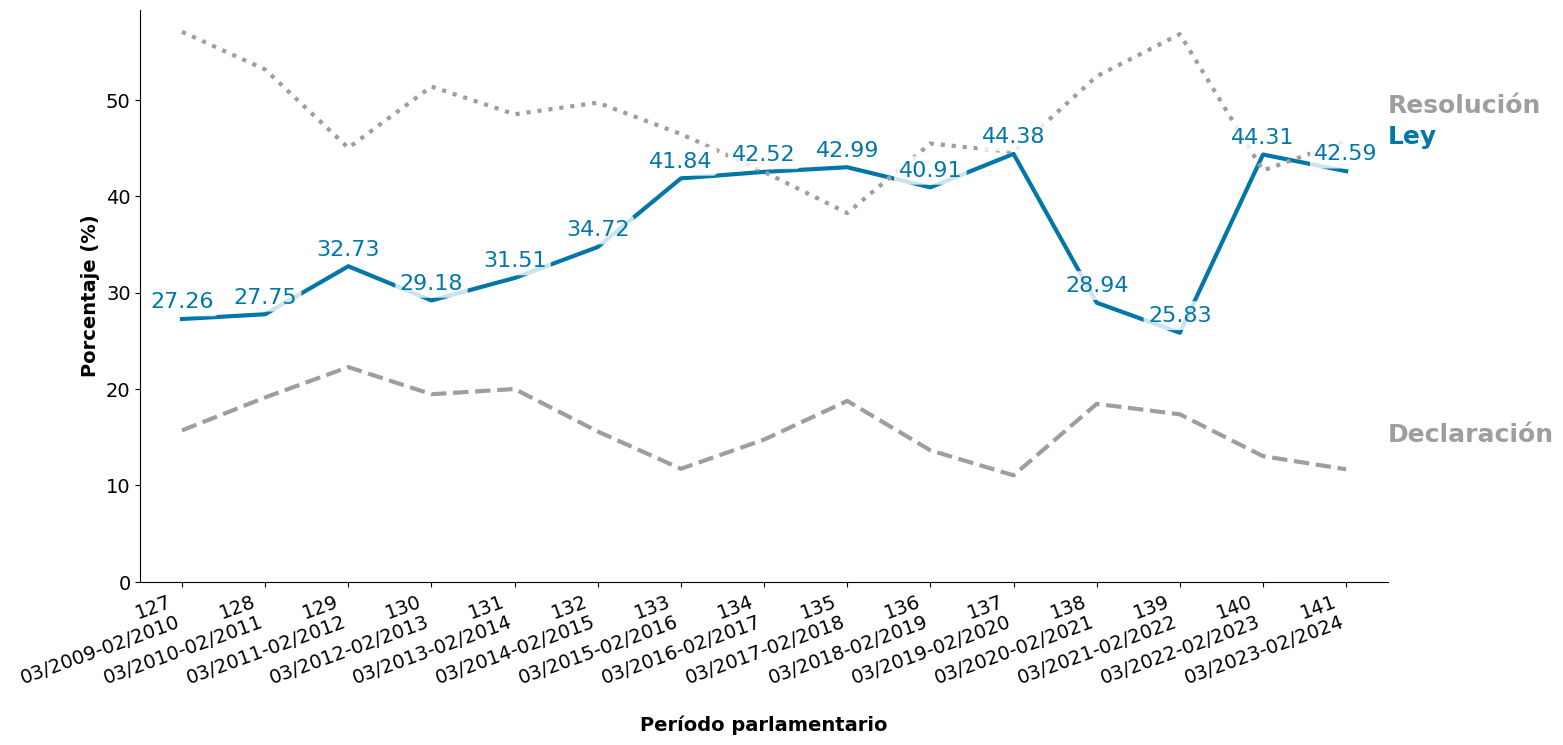

In [20]:

# Paleta de colores accesible
#colors_pie2 = ['#F15854', '#5DA5DA', '#60BD68', '#B2912F','#FAA43A']  # Rojo, Azul, Verde, Amarillo-marrón

# Paleta de colores accesible para daltonismo con 4 colores diferenciables

paleta_salud2 = {
    'ley': '#0077A8',        # azul institucional (gris medio)
    'resolución': '#1A1A1A', # casi negro (gris muy oscuro)
    'declaración': '#9FAFB8',# gris claro frío
    'otros (<1%)': '#E8EFF3' # gris muy claro
}


colors_pie2 =  [
    paleta_salud2.get(tipo.lower(), "#9E9E9E")  # fallback gris si no existe
    for tipo in tipo_percentages.columns
] 


estilos = {
    'ley':          {'linestyle': '-'},
    'resolucion':   {'linestyle': ':'},
    'declaracion':  {'linestyle': '--'},
    'otros (<1%)':  {'linestyle': '-.'},
}

map_labels = {
    'resolucion': 'Resolución',
    'ley': 'Ley',
    'declaracion': 'Declaración',
    'otros (<1%)': 'Otros (<1%)',
}

# Configurar el estilo
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 8))

# Crear el gráfico de líneas para cada tipo
for i, (tipo, color) in enumerate(zip(tipo_percentages.columns, colors_pie2)):
    if tipo.lower() != 'otros (<1%)':
        estilo = estilos.get(tipo.lower(), {'linestyle': '-'})
        ax.plot(tipo_percentages.index, tipo_percentages[tipo], 
                marker='', linewidth=3, 
                label=tipo, color=color,  **estilo )
            
        label_line_end(ax, pd.Series(tipo_percentages.index).iloc[-1], tipo_percentages[tipo].iloc[-1],
               map_labels[tipo.lower()], color,offset=(30, 25))
        if tipo in ['LEY']: 
            # Añadir anotaciones de valores porcentuales
            for periodo, valor in zip(tipo_percentages.index, tipo_percentages[tipo]):
                if valor > 0:  # Solo annotar valores mayores a 0
                    ax.annotate(f'{valor:.2f}', #f"{locale.format_string('%.2f', valor)}" , 
                               xy=(periodo, valor),
                               xytext=(0, 8), textcoords='offset points',
                               ha='center', fontsize=16,
                               color=color,
                               bbox=dict(boxstyle="round,pad=0.2", 
                                        facecolor='white', 
                                        alpha=0.8, 
                                        edgecolor='none'))

# Configurar el eje X con las fechas
xticks = sorted(tipo_percentages.index)
xtick_labels = [periodos_a_fechas(x) for x in xticks]

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, rotation=20, ha='right', fontsize=14)
ax.tick_params(axis='y', labelsize=14)


# Configuraciones del gráfico

ax.set_xlabel('Período parlamentario', 
              fontsize=14, 
              fontweight='bold', 
              labelpad=20)

ax.set_ylabel('Porcentaje (%)', fontsize=14, fontweight='bold')
#ax.set_title('Distribución porcentual de tipos de proyectos de salud por período parlamentario', 
#             fontsize=14, fontweight='bold', pad=20)

#ax.legend(title='Tipo de proyecto', loc='best', framealpha=0.9)
ax.grid(False)
ax.set_axisbelow(True)

# Formatear eje Y como porcentaje
#ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Añadir línea de referencia en 0%
#ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=0.5)

# Ajustar límites para mejor visualización
ax.set_xlim(xticks[0] - 0.5, xticks[-1] + 0.5)
ax.set_ylim(bottom=0)  # Empezar desde 0%
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Mejorar estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.set_facecolor('white')


# Añadir fondo alternado para mejor lectura de períodos
#for i, periodo in enumerate(xticks):
#    if i % 2 == 0:
#        ax.axvspan(periodo - 0.4, periodo + 0.4, alpha=0.05, color='gray')


# Ajustar el espacio entre subplots
plt.subplots_adjust(hspace=0.15)
# --- AJUSTES FINALES ---
plt.tight_layout(pad=2)
plt.subplots_adjust(hspace=0.1, bottom=0.25)  # Ajustar espacio inferior
# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/tiposProyectosdesalud.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')



# Mostrar estadísticas resumen
print("="*60)
print("RESUMEN - DISTRIBUCIÓN DE TIPOS DE PROYECTOS DE SALUD")
print("="*60)
print(f"Período analizado: {min(xticks)} - {max(xticks)}")
print(f"Total proyectos de salud: {len(salud_df)}")
print("\nDistribución general por tipo:")
for tipo in tipo_percentages.columns:
    total_tipo = tipo_counts2[tipo].sum()
    pct_tipo = (total_tipo / len(salud_df)) * 100
    print(f"  {tipo}: {total_tipo} proyectos ({pct_tipo:.1f}%)")


In [21]:
tipo_percentages.columns

Index(['DECLARACION', 'LEY', 'RESOLUCION', 'OTROS (<1%)'], dtype='object', name='Tipo')

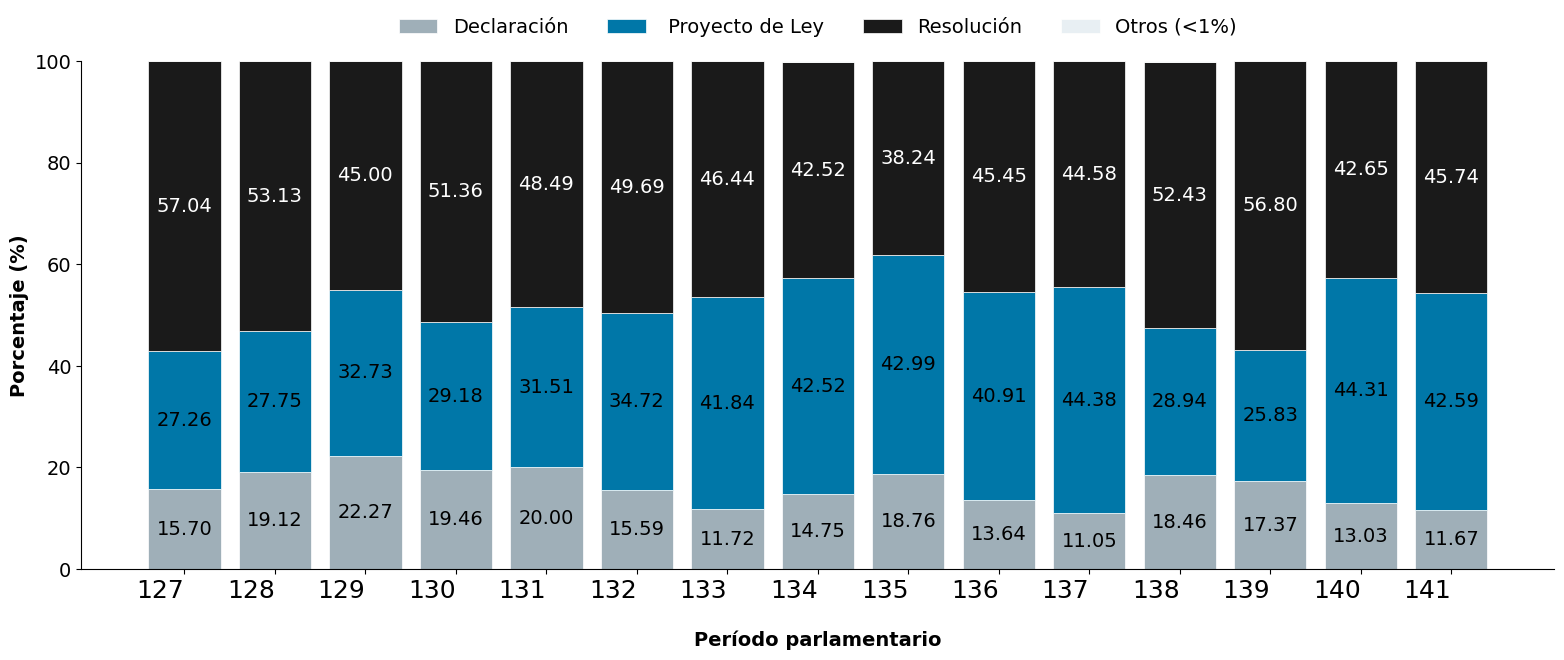

In [32]:
import numpy as np

paleta_salud = {
    'ley': '#0077A8',        # azul institucional (gris medio)
    'resolucion': '#1A1A1A', # casi negro (gris muy oscuro)
    'declaracion': '#9FAFB8',# gris claro frío
    'otros (<1%)': '#E8EFF3' # gris muy claro
}
map_labels = {
    'resolucion': 'Resolución',
    'ley': ' Proyecto de Ley',
    'declaracion': 'Declaración',
    'otros (<1%)': 'Otros (<1%)',
}

plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(tipo_percentages.index))
xticks = tipo_percentages.index
#xtick_labels = [periodos_a_fechas(p) for p in xticks]

bottom = np.zeros(len(x))

# Usar labels normalizados
for tipo in tipo_percentages.columns:

    label = map_labels.get(tipo.lower(), tipo)
    valores = tipo_percentages[tipo].values

    color = paleta_salud.get(tipo.lower(), "#9E9E9E")

    bars = ax.bar(x, valores,
                  bottom=bottom,
                  label=label,
                  color=color,
                  edgecolor='white',
                  linewidth=0.5)

    # Etiquetas internas
    for i, (b, v) in enumerate(zip(bottom, valores)):
        if v > 5:
            # Texto blanco solo para Resolución (fondo oscuro)
            text_color = 'white' if label == 'Resolución' else 'black'
            ax.text(x[i], b + v/2,
                    f'{v:.2f}',
                    ha='center', va='center',
                    fontsize=14,
                    color=text_color)


    
    bottom += valores

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(xticks, #xtick_labels,
                   #rotation=20,
                   ha='right',
                   fontsize=18)

ax.set_xlabel('Período parlamentario',
              fontsize=14,
              fontweight='bold',
              labelpad=20)

ax.set_ylabel('Porcentaje (%)',
              fontsize=14,
              fontweight='bold')

ax.set_ylim(0, 100)
ax.tick_params(axis='y', labelsize=14)

# Leyenda
legend = ax.legend(loc='upper center',
                   bbox_to_anchor=(0.5, 1.12),
                   ncol=4,
                   fontsize=14,
                   frameon=False)

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.grid(False)
ax.set_facecolor('white')

# Layout
plt.tight_layout(pad=2)
plt.subplots_adjust(bottom=0.25)

plt.savefig(BASE_DIR+'imagenes/tiposProyectosdesalud_stacked.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

plt.show()